# Pipeline 9: Resident Trajectory Archetypes

## Which resident journeys are moving toward reintegration?

**Notebook:** `resident-trajectory-archetypes.ipynb`  
**Domain:** Resident Progress and Reintegration  
**Purpose:** summarize cross-domain progress patterns and identify which residents are moving in a positive direction.

---

## 1. Problem framing

### Business question
Which combinations of history, engagement, and risk signals indicate a stronger trajectory toward reintegration?

### Predictive and explanatory goals
- **Explanatory model:** estimate which history and engagement variables move current risk up or down.
- **Predictive model:** classify whether a resident shows a positive trajectory without leaking target information.

### Who uses this
- **Case managers** to decide who needs more support
- **Supervisors** to prioritize review meetings
- **Leadership** to understand which resident journeys are improving and which are stalling

---

## 2. Data and feature engineering

### Likely sources combined in the pipeline
- Resident profile context
- Education progress aggregates
- Health service aggregates
- Process or counseling activity aggregates
- Home visitation or contact history

### Feature policy
The notebook is careful to use only information that would be available at the time of scoring. Static context such as safehouse, case category, and referral source is allowed. Historical aggregates are allowed only when they do not reveal the future target.

### Leakage control
The notebook explicitly removes `current_risk_num` because it would directly encode the target. It also keeps the label `positive_trajectory` out of the feature matrix.

---

## 3. Modeling approach

### Explanatory track
A regression-style model estimates directional effects on the current risk or trajectory proxy.

### Predictive track
A classification model predicts whether the resident has a positive trajectory.

### Validation strategy
- GroupShuffleSplit by resident
- Holdout by resident, not by row
- Standard accuracy and ROC-AUC style classification checks, plus regression-style error metrics for the explanatory track

---

## 4. What the dashboard can show

### Useful insights
- Which residents are trending upward versus stagnating
- Whether education, health, or process activity is most associated with progress
- Which residents need intervention before their trajectory worsens
- How much the current risk profile changes when the resident has more engagement history

### Decision output
This notebook supports a resident watchlist and a trajectory summary card that helps staff focus on the people most likely to benefit from support right now.

---

## 5. Caveats
This is a predictive summary of observed trajectories, not proof that any one program element caused the improvement.

## Leakage checklist

| Feature | Allowed? | Notes |
|---------|------------|-------|
| `safehouse_id`, `case_category`, `referral_source` | Yes | Static / admission context |
| Education / health / process / visitation aggregates | Yes | Historical activity totals (same-time snapshot; not future-dated) |
| **`current_risk_num`** | **Removed** | Would trivially encode components of `risk_improved` with initial risk implied |
| Label `positive_trajectory` | — | Derived from `risk_improved` OR `reint_positive`; kept out of X |

Holdout uses **20% of residents** held out entirely via `GroupShuffleSplit`.


## Visual summaries

The **next code cell** saves figures under `ml-pipelines/images/` and displays them inline:

- **`p9_trajectory_eda.png`** — outcome counts; boxplots of education progress, average health score, and counseling session count by positive vs not-positive trajectory.
- **`p9_model_summaries.png`** — permutation importance (RF), linear coefficients for risk level, holdout ROC, and actual vs predicted risk score.
- **`p9_confusion_matrix.png`** — RF confusion matrix on the resident holdout.


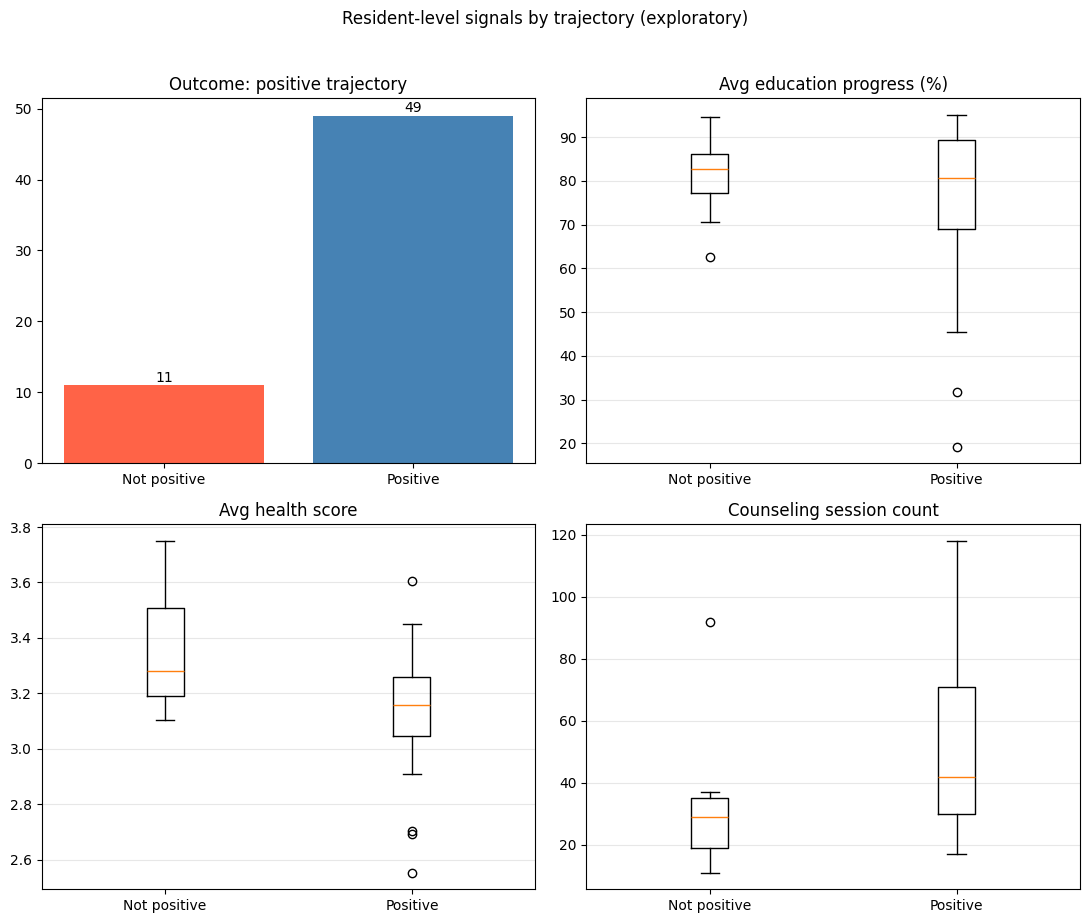

Explanatory R2: -2.87
Explanatory MAE: 1.087
Baseline AUC: 0.5
RF AUC: 1.0
RF F1: 1.0
GroupKFold CV AUC mean/std: 0.878 0.078

Top predictive drivers:
visits             0.3523
attendance_mean    0.1023
referral_source    0.0568
process_count      0.0227
safehouse_id       0.0000
case_category      0.0000
progress_mean      0.0000
edu_records        0.0000
health_mean        0.0000
sleep_mean         0.0000

Top explanatory effects (risk level):
safehouse_id_2                  -0.7179
referral_source_Self-Referral   -0.5642
safehouse_id_9                   0.4810
safehouse_id_7                  -0.4236
health_mean                     -0.4033
referral_source_Police           0.3989
safehouse_id_3                   0.3874
case_category_Surrendered       -0.3711
safehouse_id_8                  -0.3564
safehouse_id_4                   0.3439
safehouse_id_5                   0.3070
progress_mean                    0.2971

Decision recommendations: prioritize coaching where cross-domain acti

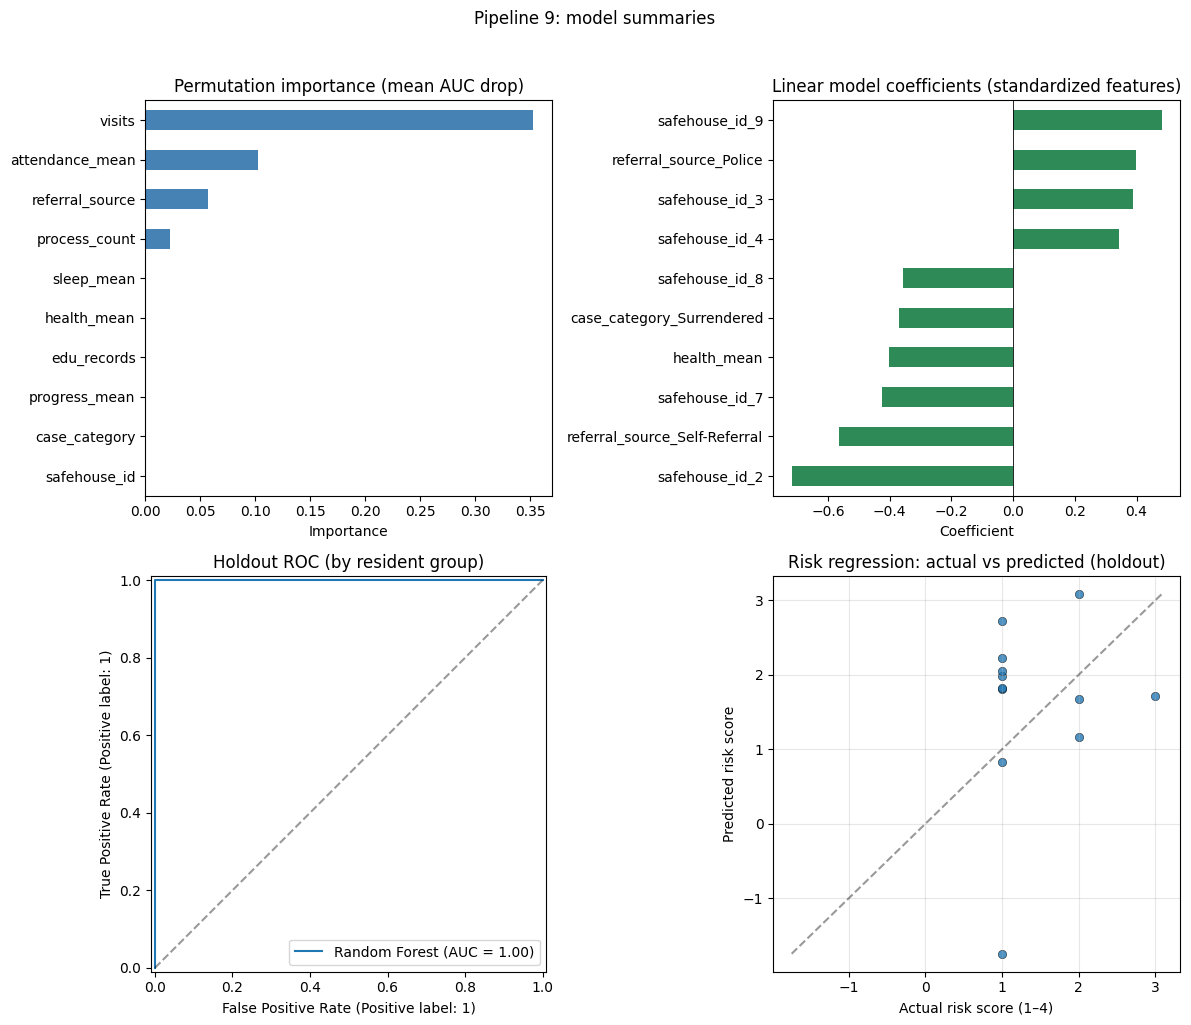

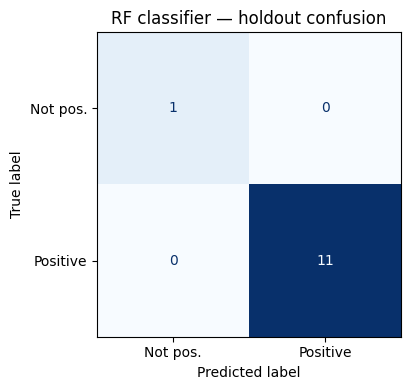

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay, f1_score, mean_absolute_error, r2_score, roc_auc_score
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

for candidate in [Path.cwd(), Path.cwd() / "ml-pipelines", Path.cwd().parent, Path.cwd().parent / "ml-pipelines"]:
    if (candidate / "data_loader.py").exists():
        sys.path.insert(0, str(candidate))
        break
from data_loader import load_table

try:
    from path_setup import artifact_dirs
    _IMAGES, _MODELS = artifact_dirs()
except Exception:
    _IMAGES = Path.cwd() / "images"
    _IMAGES.mkdir(parents=True, exist_ok=True)

res = load_table("residents").copy()
edu = load_table("education_records").copy()
health = load_table("health_wellbeing_records").copy()
proc = load_table("process_recordings").copy()
vis = load_table("home_visitations").copy()

edu_agg = edu.groupby("resident_id").agg(
    attendance_mean=("attendance_rate", "mean"),
    progress_mean=("progress_percent", "mean"),
    edu_records=("education_record_id", "count"),
)
health_agg = health.groupby("resident_id").agg(
    health_mean=("general_health_score", "mean"),
    sleep_mean=("sleep_quality_score", "mean"),
    health_records=("health_record_id", "count"),
)
proc_agg = proc.groupby("resident_id").agg(
    process_count=("recording_id", "count"),
    concerns_rate=("concerns_flagged", "mean"),
    progress_rate=("progress_noted", "mean"),
)
vis_agg = vis.groupby("resident_id").agg(
    visits=("visitation_id", "count"),
    followup_rate=("follow_up_needed", "mean"),
)

risk_order = {"Low": 1, "Medium": 2, "High": 3, "Critical": 4}
res.loc[:, "initial_risk_num"] = res["initial_risk_level"].map(risk_order)
res.loc[:, "current_risk_num"] = res["current_risk_level"].map(risk_order)
res.loc[:, "risk_improved"] = (res["current_risk_num"] < res["initial_risk_num"]).astype(int)
res.loc[:, "reint_positive"] = res["reintegration_status"].isin(["Completed", "In Progress"]).astype(int)
res.loc[:, "positive_trajectory"] = ((res["risk_improved"] == 1) | (res["reint_positive"] == 1)).astype(int)

master = (
    res[
        [
            "resident_id",
            "safehouse_id",
            "case_category",
            "referral_source",
            "current_risk_num",
            "positive_trajectory",
        ]
    ]
    .merge(edu_agg, on="resident_id", how="left")
    .merge(health_agg, on="resident_id", how="left")
    .merge(proc_agg, on="resident_id", how="left")
    .merge(vis_agg, on="resident_id", how="left")
)

features = [
    "safehouse_id",
    "case_category",
    "referral_source",
    "attendance_mean",
    "progress_mean",
    "edu_records",
    "health_mean",
    "sleep_mean",
    "health_records",
    "process_count",
    "concerns_rate",
    "progress_rate",
    "visits",
    "followup_rate",
]
num_cols = [
    "attendance_mean",
    "progress_mean",
    "edu_records",
    "health_mean",
    "sleep_mean",
    "health_records",
    "process_count",
    "concerns_rate",
    "progress_rate",
    "visits",
    "followup_rate",
]
cat_cols = ["safehouse_id", "case_category", "referral_source"]

X = master[features].copy()
for c in num_cols:
    X[c] = pd.to_numeric(X[c], errors="coerce")
for c in cat_cols:
    X[c] = X[c].astype("string").fillna("Unknown")

y_reg = master["current_risk_num"]
y_clf = master["positive_trajectory"]
groups = master["resident_id"].values

# --- EDA figures (full sample) ---
fig_eda, axes_eda = plt.subplots(2, 2, figsize=(11, 9))
traj = master["positive_trajectory"]
ax = axes_eda[0, 0]
vc = traj.value_counts().sort_index()
ax.bar(["Not positive", "Positive"], [vc.get(0, 0), vc.get(1, 0)], color=["tomato", "steelblue"])
ax.set_title("Outcome: positive trajectory")
for i, v in enumerate([vc.get(0, 0), vc.get(1, 0)]):
    ax.text(i, v + 0.5, str(int(v)), ha="center")

for ax, col, title in [
    (axes_eda[0, 1], "progress_mean", "Avg education progress (%)"),
    (axes_eda[1, 0], "health_mean", "Avg health score"),
    (axes_eda[1, 1], "process_count", "Counseling session count"),
]:
    d0 = pd.to_numeric(master.loc[traj == 0, col], errors="coerce").dropna()
    d1 = pd.to_numeric(master.loc[traj == 1, col], errors="coerce").dropna()
    ax.boxplot([d0, d1], tick_labels=["Not positive", "Positive"])
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Resident-level signals by trajectory (exploratory)", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(str(_IMAGES / "p9_trajectory_eda.png"), dpi=120, bbox_inches="tight")
plt.show()

prep = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                [
                    ("impute", SimpleImputer(strategy="median")),
                    ("scale", StandardScaler()),
                ]
            ),
            num_cols,
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            cat_cols,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
    n_jobs=1,
)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
idx_tr, idx_te = next(gss.split(X, y_clf, groups=groups))
Xtr, Xte = X.iloc[idx_tr], X.iloc[idx_te]
ytr_reg, yte_reg = y_reg.iloc[idx_tr], y_reg.iloc[idx_te]
ytrc, ytec = y_clf.iloc[idx_tr], y_clf.iloc[idx_te]

lin = Pipeline([("prep", prep), ("model", LinearRegression())])
lin.fit(Xtr, ytr_reg)
pred_reg = lin.predict(Xte)
print("Explanatory R2:", round(r2_score(yte_reg, pred_reg), 3))
print("Explanatory MAE:", round(mean_absolute_error(yte_reg, pred_reg), 3))

baseline = Pipeline([("prep", prep), ("model", DummyClassifier(strategy="prior"))])
rf = Pipeline(
    [
        ("prep", prep),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                min_samples_leaf=3,
                class_weight="balanced_subsample",
            ),
        ),
    ]
)
baseline.fit(Xtr, ytrc)
rf.fit(Xtr, ytrc)
base_proba = baseline.predict_proba(Xte)[:, 1]
rf_proba = rf.predict_proba(Xte)[:, 1]
rf_pred = (rf_proba >= 0.5).astype(int)
print("Baseline AUC:", round(roc_auc_score(ytec, base_proba), 3))
print("RF AUC:", round(roc_auc_score(ytec, rf_proba), 3))
print("RF F1:", round(f1_score(ytec, rf_pred, zero_division=0), 3))

gkf = GroupKFold(n_splits=min(5, master["resident_id"].nunique()))
cv = cross_validate(
    rf,
    X,
    y_clf,
    cv=gkf,
    scoring=["roc_auc", "f1"],
    groups=groups,
    n_jobs=1,
)
print(
    "GroupKFold CV AUC mean/std:",
    round(float(cv["test_roc_auc"].mean()), 3),
    round(float(cv["test_roc_auc"].std()), 3),
)

perm = permutation_importance(
    rf,
    Xte,
    ytec,
    n_repeats=8,
    random_state=42,
    scoring="roc_auc",
    n_jobs=1,
)
imp = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False).head(10)
print("\nTop predictive drivers:")
print(imp.round(4).to_string())

coef_values = np.ravel(lin.named_steps["model"].coef_)
coef_names = lin.named_steps["prep"].get_feature_names_out()
usable = min(len(coef_values), len(coef_names))
coef = (
    pd.Series(coef_values[:usable], index=coef_names[:usable])
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .head(12)
)
print("\nTop explanatory effects (risk level):")
print(coef.round(4).to_string())

print(
    "\nDecision recommendations: prioritize coaching where cross-domain activity signals remain weak under group holdout validation."
)

# --- Model interpretation plots ---
fig_m, axes_m = plt.subplots(2, 2, figsize=(12, 10))

ax = axes_m[0, 0]
imp.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Permutation importance (mean AUC drop)")
ax.set_xlabel("Importance")

ax = axes_m[0, 1]
topc = coef.head(10).sort_values()
topc.plot(kind="barh", ax=ax, color="seagreen")
ax.set_title("Linear model coefficients (standardized features)")
ax.set_xlabel("Coefficient")
ax.axvline(0, color="black", linewidth=0.6)

ax = axes_m[1, 0]
if ytec.nunique() >= 2:
    RocCurveDisplay.from_predictions(ytec, rf_proba, ax=ax, name="Random Forest")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_title("Holdout ROC (by resident group)")

ax = axes_m[1, 1]
ax.scatter(yte_reg, pred_reg, alpha=0.8, edgecolors="k", linewidths=0.4)
lims = [min(yte_reg.min(), pred_reg.min()), max(yte_reg.max(), pred_reg.max())]
ax.plot(lims, lims, "k--", alpha=0.4)
ax.set_xlabel("Actual risk score (1–4)")
ax.set_ylabel("Predicted risk score")
ax.set_title("Risk regression: actual vs predicted (holdout)")
ax.grid(alpha=0.3)

plt.suptitle("Pipeline 9: model summaries", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(str(_IMAGES / "p9_model_summaries.png"), dpi=120, bbox_inches="tight")
plt.show()

# Confusion matrix on holdout
if ytec.nunique() >= 2:
    fig_cm, ax_cm = plt.subplots(figsize=(4.5, 4))
    cm = confusion_matrix(ytec, rf_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Not pos.", "Positive"]).plot(ax=ax_cm, cmap="Blues", colorbar=False)
    ax_cm.set_title("RF classifier — holdout confusion")
    plt.tight_layout()
    plt.savefig(str(_IMAGES / "p9_confusion_matrix.png"), dpi=120, bbox_inches="tight")
    plt.show()


In [2]:
import sys
from pathlib import Path
for candidate in [Path.cwd(), Path.cwd() / 'ml-pipelines', Path.cwd().parent, Path.cwd().parent / 'ml-pipelines']:
    if (candidate / 'trend_eval_helpers.py').exists():
        sys.path.insert(0, str(candidate))
        break
from trend_eval_helpers import print_calibration_bins, print_threshold_scan, bootstrap_linear_coefs, fairness_binary, fairness_regression_mae

print("\n=== Evaluation artifacts ===")
if ytec.nunique() >= 2:
    proba = rf.predict_proba(Xte)[:, 1]
    print_calibration_bins(ytec.values, proba)
    print_threshold_scan(ytec.values, proba)
    fairness_binary(rf, Xte, ytec, master.loc[Xte.index], ['safehouse_id', 'case_category'], min_n=8)
bootstrap_linear_coefs(lin, Xtr, ytr_reg, n_boot=150, top_k=8)
fairness_regression_mae(lin, Xte, yte_reg, master.loc[Xte.index], ['safehouse_id'], min_n=8)



=== Evaluation artifacts ===
  bin [0.40,0.50): n=1 mean_pred=0.488 rate_pos=0.000
  bin [0.50,0.60): n=1 mean_pred=0.589 rate_pos=1.000
  bin [0.60,0.70): n=3 mean_pred=0.679 rate_pos=1.000
  bin [0.70,0.80): n=3 mean_pred=0.742 rate_pos=1.000
  bin [0.80,0.90): n=4 mean_pred=0.864 rate_pos=1.000
  thr  prec   rec    F1
  0.1  0.917  1.000  0.957
  0.2  0.917  1.000  0.957
  0.3  0.917  1.000  0.957
  0.4  0.917  1.000  0.957
  0.5  1.000  1.000  1.000
  0.6  1.000  0.909  0.952
  0.7  1.000  0.636  0.778
  0.8  1.000  0.364  0.533
  0.9  0.000  0.000  0.000

--- Fairness-style slices (AUC), min_n=8 ---
  safehouse_id=4: n=3 (skip n<min_n)
  safehouse_id=5: n=2 (skip n<min_n)
  safehouse_id=2: n=3 (skip n<min_n)
  safehouse_id=7: n=3 (skip n<min_n)
  safehouse_id=8: n=1 (skip n<min_n)
  case_category=Neglected: n=1 (skip n<min_n)
  case_category=Foundling: n=4 (skip n<min_n)
  case_category=Surrendered: n=2 (skip n<min_n)
  case_category=Abandoned: n=5 (skip n<min_n)
  feature  media